

# Experiments with Mistral as a Juge

## Loading Mistral 7b and the data

In [1]:
# Clone the repo (skip if already cloned)
!git clone https://github.com/JeremieTarantop/Cardiac-Diagnostic-CMR-report-.git repo_cmr
%cd repo_cmr

Cloning into 'repo_cmr'...
remote: Enumerating objects: 15639, done.
remote: Counting objects: 100% (15639/15639), done.
remote: Compressing objects: 100% (14891/14891), done.
remote: Total 15639 (delta 886), reused 14930 (delta 209), pack-reused 0 (from 0)
Receiving objects: 100% (15639/15639), 34.19 MiB | 38.22 MiB/s, done.
Resolving deltas: 100% (886/886), done.
/content/repo_cmr


In [2]:
from pathlib import Path

ROOT = Path(".")
MEETI_TXT_ROOT = ROOT / "data" / "20260209_MEETI TXT"
MEETI_TXT_DIR = ROOT / "data" / "20260209_MEETI TXT"

PROMPT_PATH = ROOT / "prompt_v1.txt"
assert PROMPT_PATH.exists(), f"Missing: {PROMPT_PATH}"
assert MEETI_TXT_DIR.exists(), f"Missing: {MEETI_TXT_DIR}"

BASE_PROMPT = PROMPT_PATH.read_text(encoding="utf-8").strip()

OUT_DIR = ROOT / "data" / "outputs_dpo_mistral" / "artifacts_1_2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Root:", ROOT)
print("PROMPT_PATH:", PROMPT_PATH)
print("MEETI_TXT_DIR:", MEETI_TXT_DIR)
print("OUT_DIR:", OUT_DIR)


Root: .
PROMPT_PATH: prompt_v1.txt
MEETI_TXT_DIR: data/20260209_MEETI TXT
OUT_DIR: data/outputs_dpo_mistral/artifacts_1_2


In [3]:
import json

def safe_read_text(path: Path) -> str | None:
    try:
        return path.read_text(encoding="utf-8").strip()
    except UnicodeDecodeError:
        # fallback if weird encoding slipped in
        try:
            return path.read_text(encoding="latin-1").strip()
        except Exception:
            return None
    except Exception:
        return None

def collect_meeti_records(meeti_root: Path, limit: int = 500):
    report_files = sorted(meeti_root.rglob("*_report.txt"))
    records = []
    skipped = 0

    for rf in report_files:
        rec_id = rf.name.replace("_report.txt", "")
        interp_f = rf.parent / f"{rec_id}_llm_interpretation.txt"

        short_report = safe_read_text(rf)
        llm_interp = safe_read_text(interp_f) if interp_f.exists() else None

        if not short_report or not llm_interp:
            skipped += 1
            continue

        records.append({
            "id": rec_id,
            "short_report": short_report,
            "llm_interpretation": llm_interp,
            "folder": str(rf.parent),
            "report_path": str(rf),
            "interpretation_path": str(interp_f),
        })

        if len(records) >= limit:
            break

    return records, {"found_report_files": len(report_files), "loaded": len(records), "skipped": skipped}

records, stats = collect_meeti_records(MEETI_TXT_ROOT, limit=100)
stats




{'found_report_files': 600, 'loaded': 100, 'skipped': 100}

In [4]:
!pip -q install -U transformers accelerate bitsandbytes sentencepiece

# Ensures we have:
# Latest transformers, Latest accelerate, Quantization support, Tokenizer backend
# Without version mismatches.

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_ID = "mistralai/Mistral-7B-Instruct-v0.3"

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# 4-bit config (recommended on Colab)
bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

# Model (generator)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    quantization_config=bnb_cfg,
    torch_dtype=torch.float16,
)
model.eval()
# Switches model to evaluation mode (disables dropout and training-specific behavior)
# Ensures stable, deterministic inference during generation

print("Loaded:", MODEL_ID)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.5 MB/s eta 0:00:00


config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Loaded: mistralai/Mistral-7B-Instruct-v0.3


### Loading the reports



In [5]:
from pathlib import Path

ROOT = Path(".")
MEETI_TXT_ROOT = ROOT / "data" / "20260209_MEETI TXT"
GEN_DIR = ROOT / "data" / "20260209_MEETI TXT" / "generated_reports"

assert MEETI_TXT_ROOT.exists(), f"Missing: {MEETI_TXT_ROOT}"
assert GEN_DIR.exists(), f"Missing: {GEN_DIR}"


def find_llm_interpretation_by_id(meeti_root: Path, rec_id: str) -> Path | None:
    """
    Search MEETI tree for the matching {rec_id}_llm_interpretation.txt
    Example target: .../p1000/p10000032/s40689238/{rec_id}_llm_interpretation.txt
    """
    matches = list(meeti_root.rglob(f"{rec_id}_llm_interpretation.txt"))
    if not matches:
        return None
    # Prefer the shortest path (usually the most direct match) to avoid duplicates if any
    matches.sort(key=lambda p: len(str(p)))
    return matches[0]



In [6]:
import re

def extract_response_only(text: str) -> str:
    """
    Extracts text after the SECOND occurrence of 'Response:' or '**Response:**'.
    This avoids keeping prompt scaffolding when the prompt itself contains 'Response:'.
    """

    if not text:
        return ""

    # Find all occurrences of markdown or plain Response:
    pattern = r"\*\*Response:\*\*|\bResponse:"
    matches = list(re.finditer(pattern, text))

    if len(matches) >= 2:
        # Cut after the second occurrence
        second = matches[1]
        return text[second.end():].strip()

    elif len(matches) == 1:
        # Fallback: only one found
        return text[matches[0].end():].strip()

    # If none found, return original
    return text.strip()

In [7]:
# Loading pairs of reports

def load_first_100_pairs(meeti_root: Path, gen_dir: Path):
    """
    Returns list of dicts:
      {id, generated_report, llm_interpretation, gen_path, llm_path}
    for the first 10 generated reports that have a matching llm_interpretation file.
    """
    gen_files = sorted(gen_dir.glob("*.txt"))  # generated reports are txt
    pairs = []
    skipped = 0

    for gf in gen_files:
        rec_id = gf.stem.split("_")[0]  # handles: {id}_hallucinated.txt or {id}_mistral_hallucination.txt
        raw_gen_text = safe_read_text(gf)
        if not raw_gen_text:
            skipped += 1
            continue

        gen_text = extract_response_only(raw_gen_text)

        llm_path = find_llm_interpretation_by_id(meeti_root, rec_id)
        if llm_path is None:
            skipped += 1
            continue

        llm_text = safe_read_text(llm_path)
        if not llm_text:
            skipped += 1
            continue

        pairs.append({
            "id": rec_id,
            "generated_report": gen_text,
            "llm_interpretation": llm_text,
            "gen_path": str(gf),
            "llm_path": str(llm_path),
        })

        if len(pairs) >= 100:
            break

    return pairs, {"generated_files_found": len(gen_files), "paired": len(pairs), "skipped": skipped}

pairs100, stats100 = load_first_100_pairs(MEETI_TXT_ROOT, GEN_DIR)

print(stats100)
print([p["id"] for p in pairs100])

# Example: show the first pair paths (sanity check)
if pairs100:
    print("First pair:")
    print("ID:", pairs100[0]["id"])
    print("Generated path:", pairs100[0]["gen_path"])
    print("LLM interpretation path:", pairs100[0]["llm_path"])

{'generated_files_found': 100, 'paired': 100, 'skipped': 0}
['40056908', '40067704', '40341634', '40539087', '40689238', '40695233', '40742173', '40746075', '40761639', '40816324', '40894787', '40925049', '41103859', '41309390', '41316269', '41366957', '41420867', '41445586', '41557927', '41798696', '41800350', '41997536', '42060926', '42178586', '42186899', '42315368', '42368611', '42413061', '42546971', '42695383', '42709053', '42742896', '42790963', '42855628', '42947358', '43013697', '43143228', '43468501', '43492795', '43522917', '43576724', '43647002', '43681375', '43742645', '43744967', '43749278', '44069449', '44095784', '44458630', '44669583', '44837313', '44881309', '44986768', '45090959', '45105401', '45386375', '45594411', '45808859', '45832921', '45842645', '45896667', '45986118', '46034277', '46049322', '46293961', '46440135', '46543372', '46566322', '46642833', '46743816', '46857734', '47004256', '47218930', '47226536', '47286409', '47499371', '47544594', '47843381', '47

In [8]:
# Visualization of the inputs of the judge

if pairs100:
    p = pairs100[1]

    print("="*80)
    print("PATIENT ID:", p["id"])
    print("="*80)

    print("\n--- GENERATED REPORT ---\n")
    print(p["generated_report"])

    print("\n" + "="*80)
    print("\n--- LLM INTERPRETATION ---\n")
    print(p["llm_interpretation"])

PATIENT ID: 40067704

--- GENERATED REPORT ---

Upon thorough examination of the provided ECG data, several key features and potential abnormalities have been identified.

In Lead I, the ST segment exhibits a notable elevation, which, when combined with the characteristic rsR pattern in Lead V1, suggests the presence of right ventricular hypertrophy (RVH) or right bundle branch block (RBBB). Additionally, the PR interval in Lead II indicates a possible conduction delay, potentially pointing towards atrial enlargement.

Moving to Lead II, the ST segment and T wave changes indicate an inferior wall ischemia or infarction, supporting the hypothesis of RVH or RBBB, as these conditions often involve right ventricular ischemia.

In Leads III and aVF, the presence of Q waves and ST segment and T wave changes is consistent with inferior infarction or ischemia, further supporting the diagnosis of RVH or RBBB.

The ST segment elevation in Lead aVL and the T wave inversion in Lead aVR suggest hig

In [9]:
# # This prompt is doing well (70/100)

# import json
# import re
# import torch
# from pathlib import Path
# from datetime import datetime

# JUDGE_SYSTEM = "You are a strict cardiac MRI (CMR) report judge. Follow instructions exactly."

# # Important: the example JSON must be VALID JSON (no 'A or B' inside it)
# JUDGE_INSTRUCTIONS = """
# You will compare two reports about the same case: REPORT A and REPORT B.

# Your job:
# Select the report that is more clinically realistic and less hallucinated.

# Hallucination definition:
# - Inventing findings not grounded in the case
# - Overly specific diagnoses without evidence
# - Adding structured analysis that appears templated or generic
# - Internal inconsistency

# Decision rule:
# - Prefer the report that is more cautious, evidence-based, and internally consistent.
# - If one report hallucinates and the other does not, the non-hallucinated report wins.
# - If both hallucinate, choose the less exaggerated one.

# If REPORT A is better according to the criteria, output winner="A", good_report="A", bad_report="B".
# If REPORT B is better according to the criteria, output winner="B", good_report="B", bad_report="A".

# Output ONLY valid JSON:
# {
#   "winner": "...",
#   "good_report": "...",
#   "bad_report": "..."
# }
# """.strip()

# def _extract_last_json_object(text: str) -> str:
#     """
#     Extract the last JSON object from a text blob.
#     This avoids grabbing an earlier schema example or echoed prompt.
#     """
#     # Grab all {...} blocks (non-greedy)
#     matches = re.findall(r"\{[\s\S]*?\}", text)
#     if not matches:
#         raise ValueError(f"No JSON object found. Raw output:\n{text}")

#     # Take the last one, usually the actual answer
#     cand = matches[-1].strip()

#     # Clean common issues
#     cand = re.sub(r",\s*}", "}", cand)
#     cand = re.sub(r",\s*]", "]", cand)
#     cand = re.sub(r"\bNone\b", "null", cand)
#     cand = re.sub(r"\bTrue\b", "true", cand)
#     cand = re.sub(r"\bFalse\b", "false", cand)

#     return cand

# @torch.inference_mode()
# def mistral_judge_pair(report_a: str, report_b: str, max_new_tokens: int = 120) -> dict:
#     user_prompt = (
#         JUDGE_INSTRUCTIONS
#         + "\n\nREPORT A:\n" + report_a.strip()
#         + "\n\nREPORT B:\n" + report_b.strip()
#         + "\n\nReturn JSON now."
#     )

#     messages = [
#         {"role": "system", "content": JUDGE_SYSTEM},
#         {"role": "user", "content": user_prompt},
#     ]
#     chat = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
#     inputs = tokenizer(chat, return_tensors="pt").to(model.device)

#     out = model.generate(
#         **inputs,
#         max_new_tokens=max_new_tokens,
#         do_sample=False,
#         pad_token_id=tokenizer.eos_token_id,
#         eos_token_id=tokenizer.eos_token_id,
#     )

#     decoded = tokenizer.decode(out[0], skip_special_tokens=True)
#     text = decoded[len(chat):].strip() if decoded.startswith(chat) else decoded.strip()

#     # Try parse directly
#     try:
#         obj = json.loads(text)
#         return obj
#     except json.JSONDecodeError:
#         pass

#     # Otherwise parse the last JSON object
#     cand = _extract_last_json_object(text)
#     try:
#         return json.loads(cand)
#     except json.JSONDecodeError as e:
#         raise ValueError(
#             "Model output was not valid JSON.\n\n"
#             f"--- Last JSON candidate ---\n{cand}\n\n"
#             f"--- Raw model output ---\n{text}\n"
#         ) from e

# # --- Run judge on your 10 loaded pairs ---
# JUDGE_OUT = Path("data") / "judge_results_100.jsonl"
# JUDGE_OUT.parent.mkdir(parents=True, exist_ok=True)

# results = []
# for i, p in enumerate(pairs100, start=1):
#     rec_id = p["id"]

#     report_a = p["llm_interpretation"]   # A = MEETI
#     report_b = p["generated_report"]     # B = generated

#     judgment = mistral_judge_pair(report_a, report_b)

#     row = {
#         "id": rec_id,
#         "report_A_type": "MEETI_llm_interpretation",
#         "report_B_type": "generated_hallucination",
#         "report_A_path": p["llm_path"],
#         "report_B_path": p["gen_path"],
#         "judgment": judgment,
#         "timestamp": datetime.utcnow().isoformat() + "Z",
#     }
#     results.append(row)

#     print(f"[{i}/{len(pairs100)}] {rec_id} winner={judgment.get('winner')}")

# with open(JUDGE_OUT, "w", encoding="utf-8") as f:
#     for r in results:
#         f.write(json.dumps(r, ensure_ascii=False) + "\n")

# print("Saved:", JUDGE_OUT)


#### Visualization of the results

In [10]:
# import json
# from pathlib import Path
# import matplotlib.pyplot as plt

# # Works for 10, 100, 500... just point to the right JSONL
# JUDGE_OUT = Path("data") / "judge_results_100.jsonl"
# assert JUDGE_OUT.exists(), f"Missing: {JUDGE_OUT}"

# wins_A = 0  # A = MEETI llm_interpretation
# wins_B = 0  # B = generated hallucination
# n = 0

# with open(JUDGE_OUT, "r", encoding="utf-8") as f:
#     for line in f:
#         line = line.strip()
#         if not line:
#             continue
#         obj = json.loads(line)
#         winner = obj.get("judgment", {}).get("winner")
#         if winner == "A":
#             wins_A += 1
#             n += 1
#         elif winner == "B":
#             wins_B += 1
#             n += 1
#         else:
#             # ignore malformed rows
#             pass

# assert n > 0, "No valid judged rows found."

# pct_llm = 100.0 * wins_A / n
# pct_halluc = 100.0 * wins_B / n

# labels = ["LLM interpretation (A)", "Hallucinated (B)"]
# values = [pct_llm, pct_halluc]
# colors = ["red", "grey"]

# plt.figure()
# plt.bar(labels, values, color=colors)
# plt.ylim(0, 100)
# plt.ylabel("Percent of winners (%)")
# plt.title(f"Judge winners distribution (n={n})")

# for i, v in enumerate(values):
#     plt.text(i, v + 1, f"{v:.1f}%", ha="center", va="bottom")

# plt.tight_layout()
# plt.show()


## Best working prompt

In [11]:
# This prompt is doing well (79/100) on a sample of 100 reports

import json
import re
import torch
from pathlib import Path
from datetime import datetime

JUDGE_SYSTEM = "You are a strict cardiac MRI (CMR) report JUDGE. Follow instructions exactly."

JUDGE_INSTRUCTIONS = """
You will compare two reports about the same case.

Select the report that is superior based on:

1) Clinical realism
2) Logical consistency
3) Absence of hallucination
4) Appropriate level of detail
5) No instructional or template artifacts

Hallucination includes:
- Invented findings
- Overly specific diagnoses without support
- Generic templated reasoning not grounded in the report


Do NOT reward verbosity.
Do NOT reward confidence.
Reward realism and grounded reasoning.

If REPORT A is better according to the criteria, output winner="A", good_report="A", bad_report="B".
If REPORT B is better according to the criteria, output winner="B", good_report="B", bad_report="A".

Output ONLY valid JSON:
{
  "winner": "...",
  "good_report": "...",
  "bad_report": "..."
}
""".strip()

def _extract_last_json_object(text: str) -> str:
    """
    Extract the last JSON object from a text blob.
    This avoids grabbing an earlier schema example or echoed prompt.
    """
    matches = re.findall(r"\{[\s\S]*?\}", text)
    if not matches:
        raise ValueError(f"No JSON object found. Raw output:\n{text}")

    cand = matches[-1].strip()

    cand = re.sub(r",\s*}", "}", cand)
    cand = re.sub(r",\s*]", "]", cand)
    cand = re.sub(r"\bNone\b", "null", cand)
    cand = re.sub(r"\bTrue\b", "true", cand)
    cand = re.sub(r"\bFalse\b", "false", cand)

    return cand

@torch.inference_mode()
def mistral_judge_pair(report_a: str, report_b: str, max_new_tokens: int = 120) -> dict:
    user_prompt = (
        JUDGE_INSTRUCTIONS
        + "\n\nREPORT A:\n" + report_a.strip()
        + "\n\nREPORT B:\n" + report_b.strip()
        + "\n\nReturn JSON now."
    )

    messages = [
        {"role": "system", "content": JUDGE_SYSTEM},
        {"role": "user", "content": user_prompt},
    ]
    chat = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(chat, return_tensors="pt").to(model.device)

    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    decoded = tokenizer.decode(out[0], skip_special_tokens=True)
    text = decoded[len(chat):].strip() if decoded.startswith(chat) else decoded.strip()

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    cand = _extract_last_json_object(text)
    try:
        return json.loads(cand)
    except json.JSONDecodeError as e:
        raise ValueError(
            "Model output was not valid JSON.\n\n"
            f"--- Last JSON candidate ---\n{cand}\n\n"
            f"--- Raw model output ---\n{text}\n"
        ) from e


N_PAIRS_TO_JUDGE = 100  # change this to 10, 50, 100, etc.
MAX_NEW_TOKENS = 200

# If you want the output file name to reflect N:
JUDGE_OUT = Path("data") / f"judge_results_{N_PAIRS_TO_JUDGE}.jsonl"
JUDGE_OUT.parent.mkdir(parents=True, exist_ok=True)

# Choose only the first N pairs
pairs_to_judge = pairs100[:N_PAIRS_TO_JUDGE]

results = []
total = len(pairs_to_judge)

for i, p in enumerate(pairs_to_judge, start=1):
    rec_id = p["id"]

    report_a = p["llm_interpretation"]   # A = MEETI
    report_b = p["generated_report"]     # B = generated

    judgment = mistral_judge_pair(report_a, report_b, max_new_tokens=MAX_NEW_TOKENS)

    row = {
        "id": rec_id,
        "report_A_type": "MEETI_llm_interpretation",
        "report_B_type": "generated_hallucination",
        "report_A_path": p["llm_path"],
        "report_B_path": p["gen_path"],
        "judgment": judgment,
    }
    results.append(row)

    print(f"[{i}/{total}] {rec_id} winner={judgment.get('winner')}")

with open(JUDGE_OUT, "w", encoding="utf-8") as f:
    for r in results:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print("Saved:", JUDGE_OUT)

[1/100] 40056908 winner=A
[2/100] 40067704 winner=A
[3/100] 40341634 winner=A
[4/100] 40539087 winner=A
[5/100] 40689238 winner=A
[6/100] 40695233 winner=A
[7/100] 40742173 winner=A
[8/100] 40746075 winner=A
[9/100] 40761639 winner=A
[10/100] 40816324 winner=A
[11/100] 40894787 winner=A
[12/100] 40925049 winner=B
[13/100] 41103859 winner=A
[14/100] 41309390 winner=A
[15/100] 41316269 winner=A
[16/100] 41366957 winner=A
[17/100] 41420867 winner=A
[18/100] 41445586 winner=A
[19/100] 41557927 winner=A
[20/100] 41798696 winner=A
[21/100] 41800350 winner=A
[22/100] 41997536 winner=A
[23/100] 42060926 winner=A
[24/100] 42178586 winner=A
[25/100] 42186899 winner=A
[26/100] 42315368 winner=A
[27/100] 42368611 winner=A
[28/100] 42413061 winner=A
[29/100] 42546971 winner=A
[30/100] 42695383 winner=A
[31/100] 42709053 winner=A
[32/100] 42742896 winner=B
[33/100] 42790963 winner=A
[34/100] 42855628 winner=A
[35/100] 42947358 winner=A
[36/100] 43013697 winner=A
[37/100] 43143228 winner=A
[38/100] 4

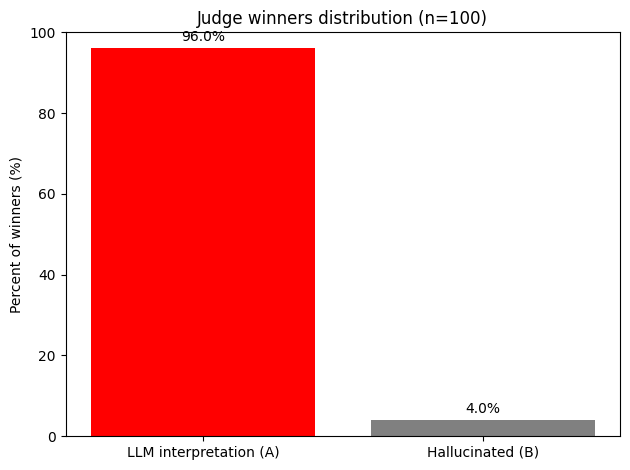

In [12]:
import json
import matplotlib.pyplot as plt

# Works for 10, 100, 500... just point to the right JSONL
JUDGE_OUT = Path("data") / "judge_results_100.jsonl"
assert JUDGE_OUT.exists(), f"Missing: {JUDGE_OUT}"

wins_A = 0  # A = MEETI llm_interpretation
wins_B = 0  # B = generated hallucination
n = 0

with open(JUDGE_OUT, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        obj = json.loads(line)
        winner = obj.get("judgment", {}).get("winner")
        if winner == "A":
            wins_A += 1
            n += 1
        elif winner == "B":
            wins_B += 1
            n += 1
        else:
            # ignore malformed rows
            pass

assert n > 0, "No valid judged rows found."

pct_llm = 100.0 * wins_A / n
pct_halluc = 100.0 * wins_B / n

labels = ["LLM interpretation (A)", "Hallucinated (B)"]
values = [pct_llm, pct_halluc]
colors = ["red", "grey"]

plt.figure()
plt.bar(labels, values, color=colors)
plt.ylim(0, 100)
plt.ylabel("Percent of winners (%)")
plt.title(f"Judge winners distribution (n={n})")

for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()


### Testing the judge ability to find good report when ECG report is also given as input

In [ ]:
# --- Judge with access to the patient's short ECG report ---

# Same instructions as above, plus explicit access to the ECG report.
JUDGE_INSTRUCTIONS_WITH_ECG = (
    JUDGE_INSTRUCTIONS
    + "\n\nYou also have access to the patient's short ECG report below. Use it as grounding when judging realism and hallucinations."
).strip()

def find_short_ecg_report_by_id(meeti_root: Path, rec_id: str) -> Path | None:
    """
    Search MEETI tree for the matching {rec_id}_report.txt (the short ECG report).
    """
    matches = list(meeti_root.rglob(f"{rec_id}_report.txt"))
    if not matches:
        return None
    matches.sort(key=lambda p: len(str(p)))
    return matches[0]

@torch.inference_mode()
def mistral_judge_pair_with_ecg(report_a: str, report_b: str, ecg_report: str, max_new_tokens: int = 160) -> dict:
    """
    Judge REPORT A vs REPORT B, with the (short) ECG report provided as additional context.

    Returns the parsed JSON judgment dict.
    """
    user_prompt = (
        JUDGE_INSTRUCTIONS_WITH_ECG
        + "\n\nECG REPORT (ground truth context):\n" + ecg_report.strip()
        + "\n\nREPORT A:\n" + report_a.strip()
        + "\n\nREPORT B:\n" + report_b.strip()
        + "\n\nReturn JSON now."
    )

    messages = [
        {"role": "system", "content": JUDGE_SYSTEM},
        {"role": "user", "content": user_prompt},
    ]
    chat = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(chat, return_tensors="pt").to(model.device)

    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    decoded = tokenizer.decode(out[0], skip_special_tokens=True)
    text = decoded[len(chat):].strip() if decoded.startswith(chat) else decoded.strip()

    # Try parse directly
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    # Otherwise parse the last JSON object
    cand = _extract_last_json_object(text)
    try:
        return json.loads(cand)
    except json.JSONDecodeError as e:
        raise ValueError(
            "Model output was not valid JSON.\n\n"
            f"--- Last JSON candidate ---\n{cand}\n\n"
            f"--- Raw model output ---\n{text}\n"
        ) from e


In [ ]:
# def run_judge_with_ecg(num_patients: int = 20,
#                        meeti_root: Path = MEETI_TXT_ROOT,
#                        gen_dir: Path = GEN_DIR,
#                        out_path: Path | None = None) -> Path:
#     """
#     Test the judge on the first `num_patients` generated-report pairs, while also providing
#     the matching short ECG report (from {id}_report.txt) as additional context.

#     Writes JSONL rows and returns the output path.
#     """
#     assert num_patients > 0, "num_patients must be > 0"

#     pairs = load_first_100_pairs(meeti_root, gen_dir)
#     pairs = pairs[:num_patients]

#     if out_path is None:
#         out_path = Path("data") / "20260309_MEETI TXT" / "generated_with_5w_ECG_reports" / f"judge_results_with_ecg_{num_patients}.jsonl"
#     out_path.parent.mkdir(parents=True, exist_ok=True)

#     results = []
#     for i, p in enumerate(pairs, start=1):
#         rec_id = p["id"]

#         # A = MEETI interpretation, B = generated report
#         report_a = p["llm_interpretation"]
#         report_b = p["generated_report"]

#         ecg_path = find_short_ecg_report_by_id(meeti_root, rec_id)
#         if ecg_path is None:
#             # Skip if we cannot locate the ECG report
#             print(f"[{i}/{len(pairs)}] {rec_id} SKIP (missing ECG report)")
#             continue

#         ecg_report = safe_read_text(ecg_path)
#         if not ecg_report:
#             print(f"[{i}/{len(pairs)}] {rec_id} SKIP (empty ECG report)")
#             continue

#         judgment = mistral_judge_pair_with_ecg(report_a, report_b, ecg_report)

#         row = {
#             "id": rec_id,
#             "report_A_type": "MEETI_llm_interpretation",
#             "report_B_type": "generated_hallucination",
#             "ecg_report_path": str(ecg_path),
#             "report_A_path": p.get("llm_path"),
#             "report_B_path": p.get("gen_path"),
#             "judgment": judgment,
#             "timestamp": datetime.utcnow().isoformat() + "Z",
#         }
#         results.append(row)

#         print(f"[{i}/{len(pairs)}] {rec_id} winner={judgment.get('winner')}")

#     with open(out_path, "w", encoding="utf-8") as f:
#         for r in results:
#             f.write(json.dumps(r, ensure_ascii=False) + "\n")

#     print("Saved:", out_path)
#     if results:
#         print("First judgment:", results[0]["judgment"])
#     return out_path



In [ ]:
def run_judge_with_ecg(num_patients: int = 100,
                       meeti_root: Path = MEETI_TXT_ROOT,
                       gen_dir: Path = GEN_DIR,
                       out_path: Path | None = None) -> Path:
    """
    Test the judge on the first `num_patients` generated-report pairs, while also providing
    the matching short ECG report (from {id}_report.txt) as additional context.

    Writes JSONL rows and returns the output path.
    """
    assert num_patients > 0, "num_patients must be > 0"

    all_pairs, _ = load_first_100_pairs(meeti_root, gen_dir)
    pairs_to_process = all_pairs[:num_patients]

    if out_path is None:
        out_path = Path("data") / "20260309_MEETI TXT" / "generated_with_5w_ECG_reports" / f"judge_results_with_ecg_{num_patients}.jsonl"
    out_path.parent.mkdir(parents=True, exist_ok=True)

    results = []
    for i, p in enumerate(pairs_to_process, start=1):
        rec_id = p["id"]

        # A = MEETI interpretation, B = generated report
        report_a = p["llm_interpretation"]
        report_b = p["generated_report"]

        ecg_path = find_short_ecg_report_by_id(meeti_root, rec_id)
        if ecg_path is None:
            # Skip if we cannot locate the ECG report
            print(f"[{i}/{len(pairs_to_process)}] {rec_id} SKIP (missing ECG report)")
            continue

        ecg_report = safe_read_text(ecg_path)
        if not ecg_report:
            print(f"[{i}/{len(pairs_to_process)}] {rec_id} SKIP (empty ECG report)")
            continue

        judgment = mistral_judge_pair_with_ecg(report_a, report_b, ecg_report)

        row = {
            "id": rec_id,
            "report_A_type": "MEETI_llm_interpretation",
            "report_B_type": "generated_hallucination",
            "ecg_report_path": str(ecg_path),
            "report_A_path": p.get("llm_path"),
            "report_B_path": p.get("gen_path"),
            "judgment": judgment,
            "timestamp": datetime.utcnow().isoformat() + "Z",
        }
        results.append(row)

        print(f"[{i}/{len(pairs_to_process)}] {rec_id} winner={judgment.get('winner')}")

    with open(out_path, "w", encoding="utf-8") as f:
        for r in results:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

    print("Saved:", out_path)
    if results:
        print("First judgment:", results[0]["judgment"])
    return out_path

out = run_judge_with_ecg(num_patients=100)


/tmp/ipython-input-217376500.py:49: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat() + "Z",


[1/100] 40056908 winner=A
[2/100] 40067704 winner=A
[3/100] 40341634 winner=A
[4/100] 40539087 winner=A
[5/100] 40689238 winner=A
[6/100] 40695233 winner=A
[7/100] 40742173 winner=A
[8/100] 40746075 winner=A
[9/100] 40761639 winner=A
[10/100] 40816324 winner=A
[11/100] 40894787 winner=A
[12/100] 40925049 winner=A
[13/100] 41103859 winner=A
[14/100] 41309390 winner=A
[15/100] 41316269 winner=A
[16/100] 41366957 winner=A
[17/100] 41420867 winner=A
[18/100] 41445586 winner=A
[19/100] 41557927 winner=A
[20/100] 41798696 winner=A
[21/100] 41800350 winner=A
[22/100] 41997536 winner=A
[23/100] 42060926 winner=A
[24/100] 42178586 winner=A
[25/100] 42186899 winner=A
[26/100] 42315368 winner=A
[27/100] 42368611 winner=A
[28/100] 42413061 winner=A
[29/100] 42546971 winner=A
[30/100] 42695383 winner=A
[31/100] 42709053 winner=A
[32/100] 42742896 winner=A
[33/100] 42790963 winner=A
[34/100] 42855628 winner=A
[35/100] 42947358 winner=A
[36/100] 43013697 winner=A
[37/100] 43143228 winner=A
[38/100] 4

In [ ]:
def preview_judge_inputs_with_ecg(
    num_patients: int = 1,
    meeti_root: Path = MEETI_TXT_ROOT,
    gen_dir: Path = GEN_DIR,
):
    """
    Prints exactly what is fed to the judge (system + full user prompt),
    without modifying your existing run_judge_with_ecg function.
    """

    all_pairs, _ = load_first_100_pairs(meeti_root, gen_dir)
    pairs_to_process = all_pairs[:num_patients]

    for i, p in enumerate(pairs_to_process, start=1):
        rec_id = p["id"]

        report_a = p["llm_interpretation"]
        report_b = p["generated_report"]

        ecg_path = find_short_ecg_report_by_id(meeti_root, rec_id)
        if ecg_path is None:
            print(f"[{i}] {rec_id} SKIP (missing ECG report)")
            continue

        ecg_report = safe_read_text(ecg_path)
        if not ecg_report:
            print(f"[{i}] {rec_id} SKIP (empty ECG report)")
            continue

        user_prompt = (
            JUDGE_INSTRUCTIONS
            + "\n\nYou now also have access to the patient's short ECG report below.\n\n"
            + "PATIENT SHORT ECG REPORT:\n"
            + ecg_report.strip()
            + "\n\nREPORT A:\n"
            + report_a.strip()
            + "\n\nREPORT B:\n"
            + report_b.strip()
            + "\n\nReturn JSON now."
        )

        print("\n" + "="*120)
        print(f"PATIENT ID: {rec_id}")
        print("="*120)

        print("\n--- SYSTEM MESSAGE ---\n")
        print(JUDGE_SYSTEM)

        print("\n" + "="*120)
        print("\n--- FULL USER PROMPT SENT TO MODEL ---\n")
        print(user_prompt)
        print("\n" + "="*120)

preview_judge_inputs_with_ecg(num_patients=1)


PATIENT ID: 40056908

--- SYSTEM MESSAGE ---

You are a strict cardiac MRI (CMR) report JUDGE. Follow instructions exactly.


--- FULL USER PROMPT SENT TO MODEL ---

You will compare two reports about the same case.

Select the report that is superior based on:

1) Clinical realism
2) Logical consistency
3) Absence of hallucination
4) Appropriate level of detail
5) No instructional or template artifacts

Hallucination includes:
- Invented findings
- Overly specific diagnoses without support
- Generic templated reasoning not grounded in the report


Do NOT reward verbosity.
Do NOT reward confidence.
Reward realism and grounded reasoning.

If REPORT A is better according to the criteria, output winner="A", good_report="A", bad_report="B". 
If REPORT B is better according to the criteria, output winner="B", good_report="B", bad_report="A".

Output ONLY valid JSON:
{
  "winner": "...",
  "good_report": "...",
  "bad_report": "..."
}

You now also have access to the patient's short ECG rep

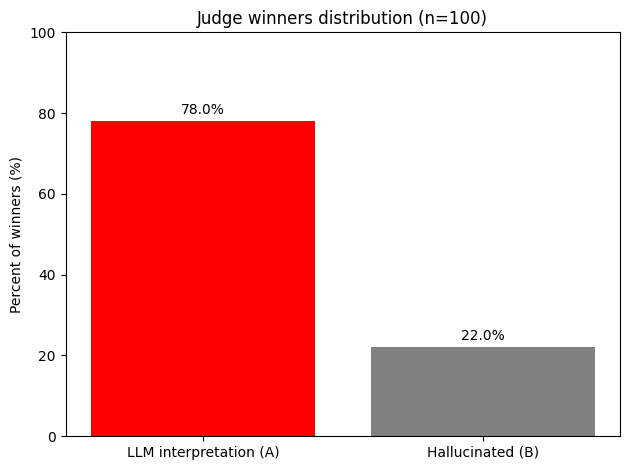

In [ ]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

def plot_judge_results_with_ecg(num_patients: int = 100,
                                base_dir: Path = Path("data") / "20260309_MEETI TXT" / "generated_with_5w_ECG_reports"):
    """
    Visualize winners distribution for judge_results_with_ecg_{num_patients}.jsonl
    """
    judge_out = base_dir / f"judge_results_with_ecg_{num_patients}.jsonl"
    assert judge_out.exists(), f"Missing: {judge_out}"

    wins_A = 0  # A = MEETI llm_interpretation
    wins_B = 0  # B = generated hallucination
    malformed = 0
    total_lines = 0

    with open(judge_out, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            total_lines += 1
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                malformed += 1
                continue

            winner = (obj.get("judgment") or {}).get("winner")
            if winner == "A":
                wins_A += 1
            elif winner == "B":
                wins_B += 1
            else:
                malformed += 1

    n_valid = wins_A + wins_B
    assert n_valid > 0, "No valid judged rows found."

    pct_A = 100.0 * wins_A / n_valid
    pct_B = 100.0 * wins_B / n_valid

    labels = ["LLM interpretation (A)", "Hallucinated (B)"]
    values = [pct_llm, pct_halluc]
    colors = ["red", "grey"]

    plt.figure()
    plt.bar(labels, values, color=colors)
    plt.ylim(0, 100)
    plt.ylabel("Percent of winners (%)")
    plt.title(f"Judge winners distribution (n={n})")

    for i, v in enumerate(values):
        plt.text(i, v + 1, f"{v:.1f}%", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()


# Example usage:
plot_judge_results_with_ecg(num_patients=100)

## Judging two reports with some ECG information (LLM interpretation VS short_ECG_report)

#### Judging without the short ECG report

In [ ]:
#Judge WITHOUT ECG context, run on first 10 pairs (5w generated reports)

import json
from pathlib import Path
from datetime import datetime

# Folder with the new, more realistic generated reports
GEN_DIR_5W = Path("data") / "20260209_MEETI TXT" / "Generated_with_5w_ECGreport"

def mistral_judge_pair_no_ecg(report_a: str, report_b: str, max_new_tokens: int = 120) -> dict:
    """
    Same judge as before, but compares REPORT A vs REPORT B with NO ECG report context.
    Uses your existing tokenizer/model objects and JSON parsing behavior.
    """
    user_prompt = (
        JUDGE_INSTRUCTIONS
        + "\n\nREPORT A:\n" + report_a.strip()
        + "\n\nREPORT B:\n" + report_b.strip()
        + "\n\nReturn JSON now."
    )

    messages = [
        {"role": "system", "content": JUDGE_SYSTEM},
        {"role": "user", "content": user_prompt},
    ]
    chat = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(chat, return_tensors="pt").to(model.device)

    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    decoded = tokenizer.decode(out[0], skip_special_tokens=True)
    text = decoded[len(chat):].strip() if decoded.startswith(chat) else decoded.strip()

    # Parse JSON output, reusing your existing helper
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        cand = _extract_last_json_object(text)
        return json.loads(cand)

def load_first_n_pairs_from_dir(meeti_root: Path, gen_dir: Path, n: int = 100):
    """
    Returns list of dicts:
      {id, generated_report, llm_interpretation, gen_path, llm_path}
    for the first n generated reports that have a matching llm_interpretation file.
    """
    assert n > 0, "n must be > 0"
    gen_files = sorted(gen_dir.glob("*.txt"))
    pairs = []
    skipped = 0

    for gf in gen_files:
        rec_id = gf.stem.split("_")[0]  # 40056908_with_report.txt -> 40056908

        raw_gen_text = safe_read_text(gf)
        if not raw_gen_text:
            skipped += 1
            continue

        gen_text = extract_response_only(raw_gen_text)  # safe even if no "Response:" exists

        llm_path = find_llm_interpretation_by_id(meeti_root, rec_id)
        if llm_path is None:
            skipped += 1
            continue

        llm_text = safe_read_text(llm_path)
        if not llm_text:
            skipped += 1
            continue

        pairs.append({
            "id": rec_id,
            "generated_report": gen_text,
            "llm_interpretation": llm_text,
            "gen_path": str(gf),
            "llm_path": str(llm_path),
        })

        if len(pairs) >= n:
            break

    stats = {"generated_files_found": len(gen_files), "paired": len(pairs), "skipped": skipped}
    return pairs, stats

def run_judge_no_ecg_on_dir(num_patients: int = 10,
                            meeti_root: Path = MEETI_TXT_ROOT,
                            gen_dir: Path = GEN_DIR_5W,
                            out_path: Path | None = None) -> Path:
    """
    Compare:
      A = MEETI llm_interpretation
      B = generated_with_5w_ecgreport
    WITHOUT giving the ECG report to the judge.
    """
    assert num_patients > 0, "num_patients must be > 0"
    assert gen_dir.exists(), f"Missing gen_dir: {gen_dir}"

    all_pairs, stats = load_first_n_pairs_from_dir(meeti_root, gen_dir, n=max(100, num_patients))
    pairs_to_process = all_pairs[:num_patients]

    print("Pairing stats:", stats)
    print("Judging pairs:", len(pairs_to_process))

    if out_path is None:
        out_path = gen_dir / f"judge_results_no_ecg_{num_patients}.jsonl"
    out_path.parent.mkdir(parents=True, exist_ok=True)

    results = []
    for i, p in enumerate(pairs_to_process, start=1):
        rec_id = p["id"]
        report_a = p["llm_interpretation"]
        report_b = p["generated_report"]

        judgment = mistral_judge_pair_no_ecg(report_a, report_b)

        row = {
            "id": rec_id,
            "report_A_type": "MEETI_llm_interpretation",
            "report_B_type": "generated_with_5w_ecgreport",
            "report_A_path": p.get("llm_path"),
            "report_B_path": p.get("gen_path"),
            "judgment": judgment,
            "timestamp": datetime.utcnow().isoformat() + "Z",
        }
        results.append(row)

        print(f"[{i}/{len(pairs_to_process)}] {rec_id} winner={judgment.get('winner')}")

    with open(out_path, "w", encoding="utf-8") as f:
        for r in results:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

    print("Saved:", out_path)
    if results:
        print("First judgment:", results[0]["judgment"])
    return out_path


In [ ]:
# # Peek at EXACT judge inputs (NO ECG), without calling the model

# from pathlib import Path

# def preview_judge_inputs_no_ecg_on_dir(num_patients: int = 1,
#                                        meeti_root: Path = MEETI_TXT_ROOT,
#                                        gen_dir: Path = GEN_DIR_5W):
#     """
#     Prints the exact inputs to the judge (system + user prompt) for the first num_patients pairs.
#     NO ECG report included.
#     """
#     assert num_patients > 0, "num_patients must be > 0"
#     assert gen_dir.exists(), f"Missing gen_dir: {gen_dir}"

#     all_pairs, stats = load_first_n_pairs_from_dir(meeti_root, gen_dir, n=max(100, num_patients))
#     pairs_to_process = all_pairs[:num_patients]

#     print("Pairing stats:", stats)
#     print("Previewing pairs:", len(pairs_to_process))

#     for i, p in enumerate(pairs_to_process, start=1):
#         rec_id = p["id"]
#         report_a = p["llm_interpretation"]
#         report_b = p["generated_report"]

#         user_prompt = (
#             JUDGE_INSTRUCTIONS
#             + "\n\nREPORT A:\n" + report_a.strip()
#             + "\n\nREPORT B:\n" + report_b.strip()
#             + "\n\nReturn JSON now."
#         )

#         print("\n" + "=" * 120)
#         print(f"[{i}] PATIENT ID: {rec_id}")
#         print("=" * 120)

#         print("\n--- PATHS ---")
#         print("Report A path:", p.get("llm_path"))
#         print("Report B path:", p.get("gen_path"))

#         print("\n--- SYSTEM MESSAGE ---\n")
#         print(JUDGE_SYSTEM)

#         print("\n" + "=" * 120)
#         print("\n--- FULL USER PROMPT SENT TO JUDGE ---\n")
#         print(user_prompt)
#         print("\n" + "=" * 120)

# # Preview the first example
# preview_judge_inputs_no_ecg_on_dir(num_patients=1, gen_dir=GEN_DIR_5W)

In [ ]:
# Run first test on 100 pairs
out_no_ecg = run_judge_no_ecg_on_dir(num_patients=100, gen_dir=GEN_DIR_5W)
out_no_ecg

Pairing stats: {'generated_files_found': 100, 'paired': 100, 'skipped': 0}
Judging pairs: 100


/tmp/ipython-input-4150416355.py:130: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat() + "Z",


[1/100] 40056908 winner=A
[2/100] 40067704 winner=A
[3/100] 40341634 winner=A
[4/100] 40539087 winner=B
[5/100] 40689238 winner=B
[6/100] 40695233 winner=A
[7/100] 40742173 winner=B
[8/100] 40746075 winner=A
[9/100] 40761639 winner=A
[10/100] 40816324 winner=A
[11/100] 40894787 winner=B
[12/100] 40925049 winner=B
[13/100] 41103859 winner=B
[14/100] 41309390 winner=B
[15/100] 41316269 winner=B
[16/100] 41366957 winner=B
[17/100] 41420867 winner=A
[18/100] 41445586 winner=A
[19/100] 41557927 winner=A
[20/100] 41798696 winner=B
[21/100] 41800350 winner=A
[22/100] 41997536 winner=A
[23/100] 42060926 winner=A
[24/100] 42178586 winner=B
[25/100] 42186899 winner=B
[26/100] 42315368 winner=A
[27/100] 42368611 winner=A
[28/100] 42413061 winner=B
[29/100] 42546971 winner=B
[30/100] 42695383 winner=A
[31/100] 42709053 winner=A
[32/100] 42742896 winner=A
[33/100] 42790963 winner=B
[34/100] 42855628 winner=A
[35/100] 42947358 winner=B
[36/100] 43013697 winner=A
[37/100] 43143228 winner=A
[38/100] 4

PosixPath('data/20260209_MEETI TXT/Generated_with_5w_ECGreport/judge_results_no_ecg_100.jsonl')

In [ ]:
import json
from pathlib import Path
from datetime import datetime

# Point to your new generated reports directory
GEN_DIR_5W = Path("data") / "20260209_MEETI TXT" / "Generated_with_5w_ECGreport"


def load_first_n_pairs_from_dir(meeti_root: Path, gen_dir: Path, n: int = 100):
    """
    Returns list of dicts:
      {id, generated_report, llm_interpretation, gen_path, llm_path}
    for the first n generated reports that have a matching llm_interpretation file.
    """
    assert n > 0, "n must be > 0"
    gen_files = sorted(gen_dir.glob("*.txt"))
    pairs = []
    skipped = 0

    for gf in gen_files:
        # For files like: 40056908_with_report.txt -> rec_id = 40056908
        rec_id = gf.stem.split("_")[0]

        raw_gen_text = safe_read_text(gf)
        if not raw_gen_text:
            skipped += 1
            continue

        # If your generated files include prompt scaffolding, keep this.
        # If not, it will just return the text unchanged.
        gen_text = extract_response_only(raw_gen_text)

        llm_path = find_llm_interpretation_by_id(meeti_root, rec_id)
        if llm_path is None:
            skipped += 1
            continue

        llm_text = safe_read_text(llm_path)
        if not llm_text:
            skipped += 1
            continue

        pairs.append({
            "id": rec_id,
            "generated_report": gen_text,
            "llm_interpretation": llm_text,
            "gen_path": str(gf),
            "llm_path": str(llm_path),
        })

        if len(pairs) >= n:
            break

    stats = {
        "generated_files_found": len(gen_files),
        "paired": len(pairs),
        "skipped": skipped,
    }
    return pairs, stats


def run_judge_with_ecg_on_dir(num_patients: int = 20,
                              meeti_root: Path = MEETI_TXT_ROOT,
                              gen_dir: Path = GEN_DIR_5W,
                              out_path: Path | None = None) -> Path:
    """
    Same logic as run_judge_with_ecg, but you can point gen_dir to any folder of generated .txt.
    Compares:
      A = MEETI llm_interpretation
      B = generated report from gen_dir
    While also giving the short ECG report to the judge as context.

    Writes JSONL rows and returns the output path.
    """
    assert num_patients > 0, "num_patients must be > 0"
    assert gen_dir.exists(), f"Missing gen_dir: {gen_dir}"

    all_pairs, stats = load_first_n_pairs_from_dir(meeti_root, gen_dir, n=max(100, num_patients))
    pairs_to_process = all_pairs[:num_patients]

    print("Pairing stats:", stats)
    print("Judging pairs:", len(pairs_to_process))

    if out_path is None:
        out_path = gen_dir / f"judge_results_with_ecg_{num_patients}.jsonl"
    out_path.parent.mkdir(parents=True, exist_ok=True)

    results = []
    for i, p in enumerate(pairs_to_process, start=1):
        rec_id = p["id"]

        # A = MEETI interpretation, B = generated report
        report_a = p["llm_interpretation"]
        report_b = p["generated_report"]

        ecg_path = find_short_ecg_report_by_id(meeti_root, rec_id)
        if ecg_path is None:
            print(f"[{i}/{len(pairs_to_process)}] {rec_id} SKIP (missing ECG report)")
            continue

        ecg_report = safe_read_text(ecg_path)
        if not ecg_report:
            print(f"[{i}/{len(pairs_to_process)}] {rec_id} SKIP (empty ECG report)")
            continue

        judgment = mistral_judge_pair_with_ecg(report_a, report_b, ecg_report)

        row = {
            "id": rec_id,
            "report_A_type": "MEETI_llm_interpretation",
            "report_B_type": "generated_with_5w_ecgreport",
            "ecg_report_path": str(ecg_path),
            "report_A_path": p.get("llm_path"),
            "report_B_path": p.get("gen_path"),
            "judgment": judgment,
            "timestamp": datetime.utcnow().isoformat() + "Z",
        }
        results.append(row)

        print(f"[{i}/{len(pairs_to_process)}] {rec_id} winner={judgment.get('winner')}")

    with open(out_path, "w", encoding="utf-8") as f:
        for r in results:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

    print("Saved:", out_path)
    if results:
        print("First judgment:", results[0]["judgment"])
    return out_path



In [ ]:
from pathlib import Path

def preview_judge_inputs_with_ecg_on_dir(num_patients: int = 1,
                                        meeti_root: Path = MEETI_TXT_ROOT,
                                        gen_dir: Path = GEN_DIR_5W):

    assert gen_dir.exists(), f"Missing gen_dir: {gen_dir}"

    all_pairs, stats = load_first_n_pairs_from_dir(meeti_root, gen_dir, n=max(100, num_patients))
    pairs_to_process = all_pairs[:num_patients]

    print("Pairing stats:", stats)
    print("Previewing pairs:", len(pairs_to_process))

    for i, p in enumerate(pairs_to_process, start=1):
        rec_id = p["id"]
        report_a = p["llm_interpretation"]
        report_b = p["generated_report"]

        ecg_path = find_short_ecg_report_by_id(meeti_root, rec_id)
        if ecg_path is None:
            print(f"[{i}] {rec_id} SKIP (missing ECG report)")
            continue

        ecg_report = safe_read_text(ecg_path)
        if not ecg_report:
            print(f"[{i}] {rec_id} SKIP (empty ECG report)")
            continue

        # Build the exact user prompt that SHOULD be sent to the judge
        # (this mirrors the typical structure used by mistral_judge_pair_with_ecg)
        user_prompt = (
            JUDGE_INSTRUCTIONS
            + "\n\nYou now also have access to the patient's short ECG report below.\n\n"
            + "PATIENT SHORT ECG REPORT:\n"
            + ecg_report.strip()
            + "\n\nREPORT A:\n"
            + report_a.strip()
            + "\n\nREPORT B:\n"
            + report_b.strip()
            + "\n\nReturn JSON now."
        )

        print("\n" + "=" * 120)
        print(f"[{i}] PATIENT ID: {rec_id}")
        print("=" * 120)

        print("\n--- PATHS ---")
        print("ECG report path:", str(ecg_path))
        print("Report A path:", p.get("llm_path"))
        print("Report B path:", p.get("gen_path"))

        print("\n--- SYSTEM MESSAGE ---\n")
        print(JUDGE_SYSTEM)

        print("\n" + "=" * 120)
        print("\n--- FULL USER PROMPT SENT TO JUDGE ---\n")
        print(user_prompt)
        print("\n" + "=" * 120)

preview_judge_inputs_with_ecg_on_dir(num_patients=1, gen_dir=GEN_DIR_5W)

Pairing stats: {'generated_files_found': 100, 'paired': 100, 'skipped': 0}
Previewing pairs: 1

[1] PATIENT ID: 40056908

--- PATHS ---
ECG report path: data/20260209_MEETI TXT/p1000/p10001877/s40056908/40056908_report.txt
Report A path: data/20260209_MEETI TXT/p1000/p10001877/s40056908/40056908_llm_interpretation.txt
Report B path: data/20260209_MEETI TXT/Generated_with_5w_ECGreport/40056908_with_report.txt

--- SYSTEM MESSAGE ---

You are a strict cardiac MRI (CMR) report JUDGE. Follow instructions exactly.


--- FULL USER PROMPT SENT TO JUDGE ---

You will compare two reports about the same case.

Select the report that is superior based on:

1) Clinical realism
2) Logical consistency
3) Absence of hallucination
4) Appropriate level of detail
5) No instructional or template artifacts

Hallucination includes:
- Invented findings
- Overly specific diagnoses without support
- Generic templated reasoning not grounded in the report


Do NOT reward verbosity.
Do NOT reward confidence.
Rew

In [ ]:

# ---- Test on 100 pairs first ----
out = run_judge_with_ecg_on_dir(num_patients=100, gen_dir=GEN_DIR_5W)
print("Output:", out)

Pairing stats: {'generated_files_found': 100, 'paired': 100, 'skipped': 0}
Judging pairs: 100


/tmp/ipython-input-1528162657.py:116: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat() + "Z",


[1/100] 40056908 winner=A
[2/100] 40067704 winner=A
[3/100] 40341634 winner=A
[4/100] 40539087 winner=A
[5/100] 40689238 winner=A
[6/100] 40695233 winner=A
[7/100] 40742173 winner=A
[8/100] 40746075 winner=A
[9/100] 40761639 winner=A
[10/100] 40816324 winner=A
[11/100] 40894787 winner=A
[12/100] 40925049 winner=A
[13/100] 41103859 winner=A
[14/100] 41309390 winner=A
[15/100] 41316269 winner=B
[16/100] 41366957 winner=A
[17/100] 41420867 winner=A
[18/100] 41445586 winner=A
[19/100] 41557927 winner=A
[20/100] 41798696 winner=A
[21/100] 41800350 winner=A
[22/100] 41997536 winner=A
[23/100] 42060926 winner=A
[24/100] 42178586 winner=A
[25/100] 42186899 winner=A
[26/100] 42315368 winner=A
[27/100] 42368611 winner=A
[28/100] 42413061 winner=A
[29/100] 42546971 winner=A
[30/100] 42695383 winner=A
[31/100] 42709053 winner=A
[32/100] 42742896 winner=A
[33/100] 42790963 winner=A
[34/100] 42855628 winner=A
[35/100] 42947358 winner=A
[36/100] 43013697 winner=A
[37/100] 43143228 winner=A
[38/100] 4

#### Creating graphs for the presentation

In [ ]:
import re

def count_winner_B(log_text: str) -> int:
    """
    Counts how many times winner=B appears in the provided log text.
    Double checks by matching full pattern 'winner=B'.
    """
    matches = re.findall(r"winner=B\b", log_text)
    return len(matches)

In [ ]:
log_text = """

[1/100] 40056908 winner=A
[2/100] 40067704 winner=A
[3/100] 40341634 winner=A
[4/100] 40539087 winner=A
[5/100] 40689238 winner=A
[6/100] 40695233 winner=A
[7/100] 40742173 winner=A
[8/100] 40746075 winner=A
[9/100] 40761639 winner=A
[10/100] 40816324 winner=A
[11/100] 40894787 winner=A
[12/100] 40925049 winner=A
[13/100] 41103859 winner=A
[14/100] 41309390 winner=A
[15/100] 41316269 winner=A
[16/100] 41366957 winner=A
[17/100] 41420867 winner=A
[18/100] 41445586 winner=A
[19/100] 41557927 winner=A
[20/100] 41798696 winner=A
[21/100] 41800350 winner=A
[22/100] 41997536 winner=A
[23/100] 42060926 winner=A
[24/100] 42178586 winner=A
[25/100] 42186899 winner=A
[26/100] 42315368 winner=A
[27/100] 42368611 winner=A
[28/100] 42413061 winner=A
[29/100] 42546971 winner=A
[30/100] 42695383 winner=A
[31/100] 42709053 winner=A
[32/100] 42742896 winner=A
[33/100] 42790963 winner=A
[34/100] 42855628 winner=A
[35/100] 42947358 winner=A
[36/100] 43013697 winner=A
[37/100] 43143228 winner=A
[38/100] 43468501 winner=A
[39/100] 43492795 winner=A
[40/100] 43522917 winner=A
[41/100] 43576724 winner=A
[42/100] 43647002 winner=A
[43/100] 43681375 winner=A
[44/100] 43742645 winner=A
[45/100] 43744967 winner=A
[46/100] 43749278 winner=A
[47/100] 44069449 winner=A
[48/100] 44095784 winner=A
[49/100] 44458630 winner=A
[50/100] 44669583 winner=A
[51/100] 44837313 winner=A
[52/100] 44881309 winner=A
[53/100] 44986768 winner=A
[54/100] 45090959 winner=A
[55/100] 45105401 winner=A
[56/100] 45386375 winner=A
[57/100] 45594411 winner=A
[58/100] 45808859 winner=A
[59/100] 45832921 winner=A
[60/100] 45842645 winner=A
[61/100] 45896667 winner=A
[62/100] 45986118 winner=A
[63/100] 46034277 winner=A
[64/100] 46049322 winner=A
[65/100] 46293961 winner=A
[66/100] 46440135 winner=A
[67/100] 46543372 winner=A
[68/100] 46566322 winner=A
[69/100] 46642833 winner=A
[70/100] 46743816 winner=A
[71/100] 46857734 winner=A
[72/100] 47004256 winner=A
[73/100] 47218930 winner=A
[74/100] 47226536 winner=A
[75/100] 47286409 winner=A
[76/100] 47499371 winner=A
[77/100] 47544594 winner=A
[78/100] 47843381 winner=A
[79/100] 47863823 winner=A
[80/100] 48132909 winner=A
[81/100] 48142435 winner=A
[82/100] 48150809 winner=A
[83/100] 48288896 winner=A
[84/100] 48339811 winner=A
[85/100] 48376834 winner=A
[86/100] 48446569 winner=A
[87/100] 48531703 winner=A
[88/100] 48575806 winner=A
[89/100] 48582094 winner=A
[90/100] 48778222 winner=A
[91/100] 49036311 winner=A
[92/100] 49144190 winner=A
[93/100] 49202548 winner=A
[94/100] 49245181 winner=A
[95/100] 49368993 winner=A
[96/100] 49466912 winner=A
[97/100] 49500365 winner=A
[98/100] 49560547 winner=A
[99/100] 49758073 winner=A
[100/100] 49961002 winner=A


"""

print("Number of winner=B:", count_winner_B(log_text))

Number of winner=B: 0


In [ ]:
import matplotlib.pyplot as plt

def plot_manual_judge_distribution(pct_B: float,
                                    n: int = 100,
                                    label_A: str = "LLM interpretation (A)",
                                    label_B: str = "Generated report (B)"):
    """
    Create a judge-style bar plot using a manually provided percentage for B.

    pct_B: percentage of B wins (0–100)
    n: total number of samples (used only for title display)
    """

    assert 0 <= pct_B <= 100, "pct_B must be between 0 and 100"

    pct_A = 100.0 - pct_B

    labels = [label_A, label_B]
    values = [pct_A, pct_B]
    colors = ["red", "grey"]

    plt.figure(figsize=(6, 4))
    bars = plt.bar(labels, values, color=colors)

    plt.ylim(0, 100)
    plt.ylabel("Percent of winners (%)")
    plt.title(f"Judge winners distribution with good fake reports (n={n})")

    for bar, v in zip(bars, values):
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()
        plt.text(x, y - 10, f"{v:.1f}%", ha="center", va="center")

    plt.tight_layout()
    plt.show()

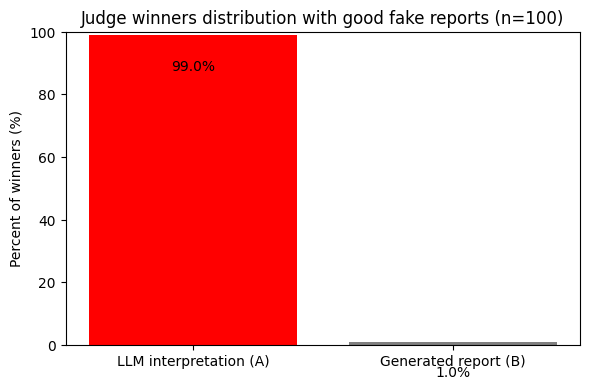

In [ ]:
plot_manual_judge_distribution(pct_B=1, n=100)